In [3]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

try:
    engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}')
    query="""
            select
                o.order_purchase_timestamp::date as order_day,
                oi.product_id,
                p.product_category_name as category_name,
                sum(oi.price) as revenue 
            from
                analytics.fact_orders_items oi
            left join
                analytics.fact_orders o
                on o.order_id = oi.order_id
            left join        
		        analytics.dim_products p
                on p.product_id = oi.product_id
            where
                product_category_name is not null
            group by
                p.product_category_name, oi.product_id, o.order_purchase_timestamp
            order by
                o.order_purchase_timestamp asc;
        """
    analysis_df = pd.read_sql(query, con=engine)
 
except Exception as e:
    print(f"Detail error: {e}")
finally:
    engine.dispose()

## Exploratory analysis of the dataset

In [4]:
analysis_df

,order_day,product_id,category_name,revenue
0,2016-09-04,c1488892604e4ba5cff5b4eb4d595400,moveis_decoracao,79.98
1,2016-09-04,f293394c72c9b5fafd7023301fc21fc2,moveis_decoracao,65.80
2,2016-09-05,f3c2d01a84c947b078e32bbef0718962,telefonia,59.50
3,2016-09-15,5a6b04657a4c5ee34285d1e4619a96b4,beleza_saude,404.91
4,2016-10-02,d2998d7ced12f83f9b832f33cf6507b6,bebes,100.00
...,...,...,...,...
100928,2018-08-29,2b4472df15512a2825ae86fd9ae79335,moveis_cozinha_area_de_servico_jantar_e_jardim,836.00
100929,2018-08-29,bdcf6a834e8faa30dac3886c7a58e92e,beleza_saude,45.90
100930,2018-08-29,c7f27c5bef2338541c772b5776403e6a,artigos_de_festas,24.90
100931,2018-08-29,d04857e7b4b708ee8b8b9921163edba3,informatica_acessorios,84.99


In [5]:
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100933 entries, 0 to 100932
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_day      100933 non-null  object 
 1   product_id     100933 non-null  str    
 2   category_name  100933 non-null  str    
 3   revenue        100933 non-null  float64
dtypes: float64(1), object(1), str(2)
memory usage: 3.1+ MB


In [6]:
analysis_df.isnull().sum()

order_day        0
product_id       0
category_name    0
revenue          0
dtype: int64

In [7]:
analysis_df = analysis_df.drop("product_id", axis=1)

In [8]:
analysis_df

,order_day,category_name,revenue
0,2016-09-04,moveis_decoracao,79.98
1,2016-09-04,moveis_decoracao,65.80
2,2016-09-05,telefonia,59.50
3,2016-09-15,beleza_saude,404.91
4,2016-10-02,bebes,100.00
...,...,...,...
100928,2018-08-29,moveis_cozinha_area_de_servico_jantar_e_jardim,836.00
100929,2018-08-29,beleza_saude,45.90
100930,2018-08-29,artigos_de_festas,24.90
100931,2018-08-29,informatica_acessorios,84.99


In [9]:
analysis_df = (analysis_df.groupby(["order_day", "category_name"])["revenue"].sum().reset_index())

In [10]:
analysis_df["order_day"] = pd.to_datetime(analysis_df["order_day"])
analysis_df.set_index("order_day", inplace=True)

In [11]:
analysis_df

,category_name,revenue
order_day,,
2016-09-04,moveis_decoracao,145.78
2016-09-05,telefonia,59.50
2016-09-15,beleza_saude,404.91
2016-10-02,bebes,100.00
2016-10-03,brinquedos,128.90
...,...,...
2018-08-29,esporte_lazer,6.90
2018-08-29,informatica_acessorios,84.99
2018-08-29,moveis_cozinha_area_de_servico_jantar_e_jardim,836.00


In [12]:
analysis_df["revenue"].describe()

count     18504.000000
mean        919.513379
std        1706.708582
min           3.500000
25%         129.797500
50%         400.845000
75%        1099.077500
max      107520.000000
Name: revenue, dtype: float64

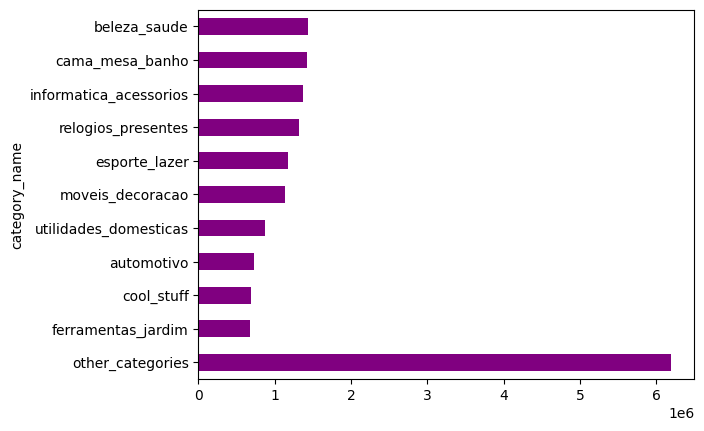

In [15]:
top_10 = analysis_df.groupby('category_name')['revenue'].sum().sort_values(ascending=False).head(10)
other = analysis_df.groupby('category_name')['revenue'].sum().sort_values(ascending=False).iloc[10:].sum()

top_10["other_categories"] = other

top_10.plot(kind='barh', color='purple').invert_yaxis()

